<h1><center><b>Session 6 Multivariate Analysis</b></center></h1>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
visa_df=pd.read_csv(r"E:\Python Projects\Data Files\Visadataset.csv")

cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [6]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [8]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [10]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


- **Variate :** Variables

- **Bi-Variate :** Two variable analysis

- **Multi-Variate :** More than two variable analysis

- Total

In [13]:
visa_df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [15]:
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

- **STEP - 1 :** Condition1 = case_status == 'Certified'

- **STEP - 2 :** Condition2 = continent == 'Asia'

- **STEP - 3 :** Condition =  condition1 & condition2

- **STEP - 4 :** visa_df[condition]

- **STEP - 5 :** len(visa_df[condition])

In [29]:
con1=visa_df['case_status']=='Certified'
con2=visa_df['continent']=='Asia'
con=con1&con2
len(visa_df[con])

11012

In [31]:
con1=visa_df['case_status']=='Certified'
con2=visa_df['continent']=='Asia'
con=con1&con2
print(visa_df[con])
len(visa_df[con])

         case_id continent education_of_employee has_job_experience  \
1         EZYV02      Asia              Master's                  Y   
5         EZYV06      Asia              Master's                  Y   
6         EZYV07      Asia            Bachelor's                  N   
8         EZYV09      Asia            Bachelor's                  N   
10        EZYV11      Asia              Master's                  N   
...          ...       ...                   ...                ...   
25475  EZYV25476      Asia            Bachelor's                  Y   
25476  EZYV25477      Asia           High School                  Y   
25477  EZYV25478      Asia              Master's                  Y   
25478  EZYV25479      Asia              Master's                  Y   
25479  EZYV25480      Asia            Bachelor's                  Y   

      requires_job_training  no_of_employees  yr_of_estab  \
1                         N             2412         2002   
5                        

11012

In [37]:
certi_con=visa_df['case_status']=='Certified'
denied_con=visa_df['case_status']=='Denied'
con=visa_df['continent']=='Asia'     # Change

certi_data=certi_con & con
den_data=denied_con & con

len(visa_df[certi_data]),len(visa_df[den_data])

(11012, 5849)

In [39]:
labels=visa_df['continent'].value_counts().keys()
for i in labels:
    certi_con=visa_df['case_status']=='Certified'
    denied_con=visa_df['case_status']=='Denied'
    con=visa_df['continent']==i     # Change
    
    certi_data=certi_con & con
    den_data=denied_con & con
    
    print(len(visa_df[certi_data]),len(visa_df[den_data]))

11012 5849
2957 775
2037 1255
493 359
397 154
122 70


In [51]:
labels=visa_df['continent'].value_counts().keys()
certi_count,den_count=[],[]
for i in labels:
    certi_con=visa_df['case_status']=='Certified'
    denied_con=visa_df['case_status']=='Denied'
    con=visa_df['continent']==i     # Change
    
    certi_data=certi_con & con
    den_data=denied_con & con

    certi_count.append(len(visa_df[certi_data]))
    den_count.append(len(visa_df[den_data]))

certi_count,den_count

([11012, 2957, 2037, 493, 397, 122], [5849, 775, 1255, 359, 154, 70])

In [55]:
cols=visa_df['case_status'].value_counts().keys()
pd.DataFrame(zip(certi_con,den_count),
             index=labels,
            columns=cols)

case_status,Certified,Denied
continent,,
Asia,False,5849
Europe,True,775
North America,False,1255
South America,False,359
Africa,True,154
Oceania,True,70


# pd.Crosstab :

pd.crosstab() :

Signature:
pd.crosstab(
    index,
    columns,
    values=None,
    rownames=None,
    colnames=None,
    aggfunc=None,
    margins: 'bool' = False,
    margins_name: 'Hashable' = 'All',
    dropna: 'bool' = True,
    normalize: "bool | Literal[0, 1, 'all', 'index', 'columns']" = False,
) -> 'DataFrame'
Docstring:
Compute a simple cross tabulation of two (or more) factors.

By default, computes a frequency table of the factors unless an
array of values and an aggregation function are passed.

Parameters
----------
index : array-like, Series, or list of arrays/Series
    Values to group by in the rows.
columns : array-like, Series, or list of arrays/Series
    Values to group by in the columns.
values : array-like, optional
    Array of values to aggregate according to the factors.
    Requires `aggfunc` be specified.
rownames : sequence, default None
    If passed, must match number of row arrays passed.
colnames : sequence, default None
    If passed, must match number of column arrays passed.
aggfunc : function, optional
    If specified, requires `values` be specified as well.
margins : bool, default False
    Add row/column margins (subtotals).
margins_name : str, default 'All'
    Name of the row/column that will contain the totals
    when margins is True.
dropna : bool, default True
    Do not include columns whose entries are all NaN.
normalize : bool, {'all', 'index', 'columns'}, or {0,1}, default False
    Normalize by dividing all values by the sum of values.

    - If passed 'all' or `True`, will normalize over all values.
    - If passed 'index' will normalize over each row.
    - If passed 'columns' will normalize over each column.
    - If margins is `True`, will also normalize margin values.

Returns
-------
DataFrame
    Cross tabulation of the data.

See Also
--------
DataFrame.pivot : Reshape data based on column values.
pivot_table : Create a pivot table as a DataFrame.

Notes
-----
Any Series passed will have their name attributes used unless row or column
names for the cross-tabulation are specified.

Any input passed containing Categorical data will have **all** of its
categories included in the cross-tabulation, even if the actual data does
not contain any instances of a particular category.

In the event that there aren't overlapping indexes an empty DataFrame will
be returned.

Reference :ref:`the user guide <reshaping.crosstabulations>` for more examples.

Examples
--------
>>> a = np.array(["foo", "foo", "foo", "foo", "bar", "bar",
...               "bar", "bar", "foo", "foo", "foo"], dtype=object)
>>> b = np.array(["one", "one", "one", "two", "one", "one",
...               "one", "two", "two", "two", "one"], dtype=object)
>>> c = np.array(["dull", "dull", "shiny", "dull", "dull", "shiny",
...               "shiny", "dull", "shiny", "shiny", "shiny"],
...              dtype=object)
>>> pd.crosstab(a, [b, c], rownames=['a'], colnames=['b', 'c'])
b   one        two
c   dull shiny dull shiny
a
bar    1     2    1     0
foo    2     2    1     2

Here 'c' and 'f' are not represented in the data and will not be
shown in the output because dropna is True by default. Set
dropna=False to preserve categories with no data.

>>> foo = pd.Categorical(['a', 'b'], categories=['a', 'b', 'c'])
>>> bar = pd.Categorical(['d', 'e'], categories=['d', 'e', 'f'])
>>> pd.crosstab(foo, bar)
col_0  d  e
row_0
a      1  0
b      0  1
>>> pd.crosstab(foo, bar, dropna=False)
col_0  d  e  f
row_0
a      1  0  0
b      0  1  0
c      0  0  0

In [58]:
col1=visa_df['case_status']
col2=visa_df['continent']
pd.crosstab(col1,col2)

continent,Africa,Asia,Europe,North America,Oceania,South America
case_status,,,,,,
Certified,397,11012,2957,2037,122,493
Denied,154,5849,775,1255,70,359


In [60]:
col1=visa_df['case_status']
col2=visa_df['continent']
pd.crosstab(col2,col1)

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [62]:
col1=visa_df['case_status']
col2=visa_df['continent']
r1=pd.crosstab(col2,col1)

<Axes: ylabel='Frequency'>

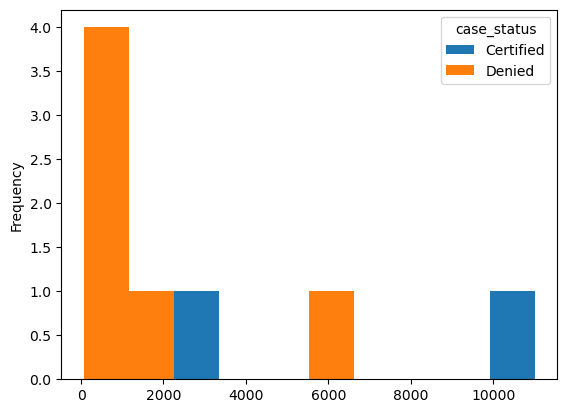

In [64]:
r1.plot(kind='hist')

<Axes: xlabel='continent'>

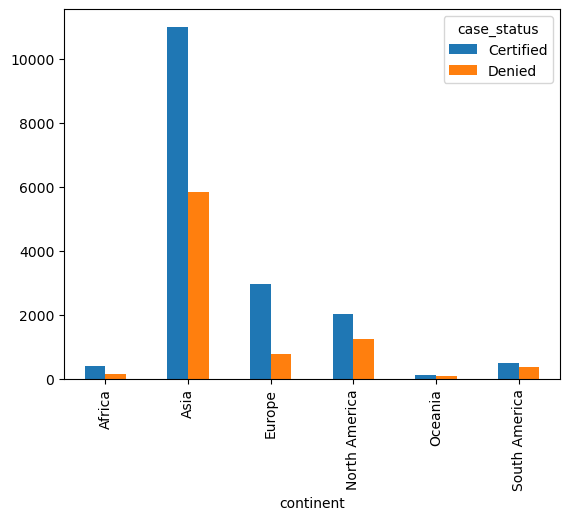

In [66]:
r1.plot(kind='bar')

<Axes: >

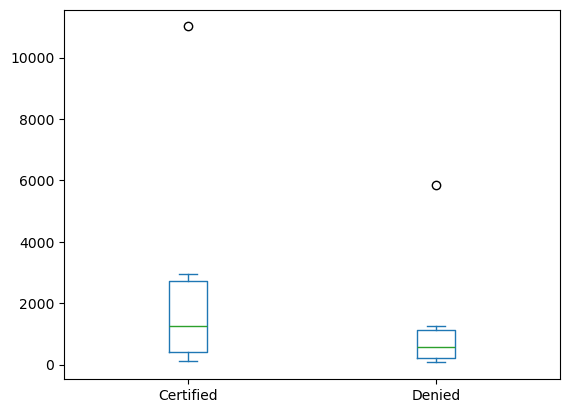

In [68]:
r1.plot(kind='box')

# Task :
- To know how many **certified** from asia
  - How many **PhD** graduates are there

In [86]:
col1=visa_df['case_status']
col2=visa_df['continent']
col3=visa_df['education_of_employee']
Id=col2
cols=[col1,col3]
pd.crosstab(col2,cols)

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

# Numerical Column Analysis :
 - Scatter plot

 - Correlation

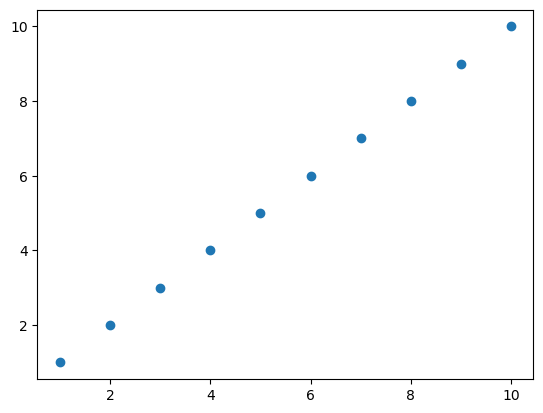

In [89]:
x=range(1,11)
y=range(1,11)
plt.scatter(x,y)

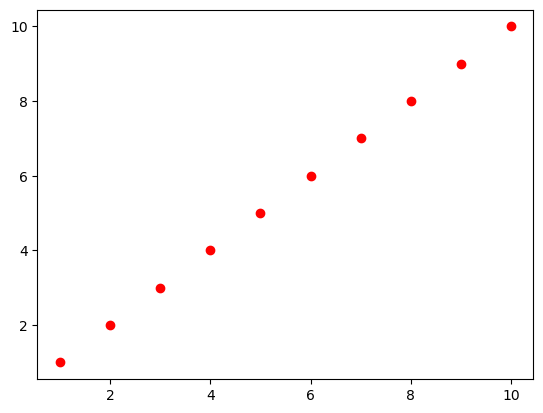

In [91]:
x=range(1,11)
y=range(1,11)
plt.scatter(x,y,c='Red')

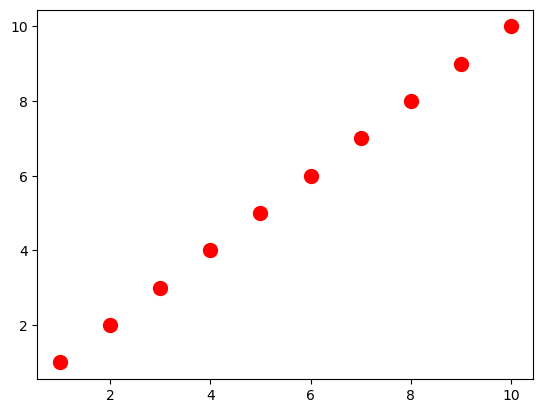

In [93]:
x=range(1,11)
y=range(1,11)
plt.scatter(x,y,c='Red',s=100)

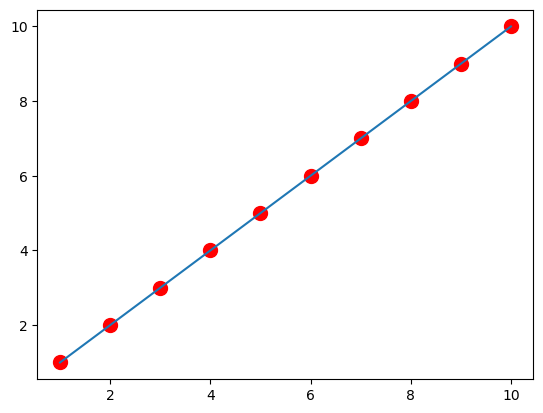

In [97]:
x=range(1,11)
y=range(1,11)
plt.scatter(x,y,c='Red',s=100)
plt.plot(x,y)

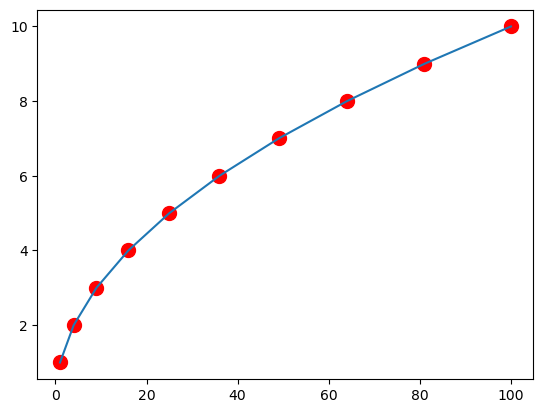

In [103]:
x=np.square(range(1,11))
y=range(1,11)
plt.scatter(x,y,c='Red',s=100)
plt.plot(x,y)

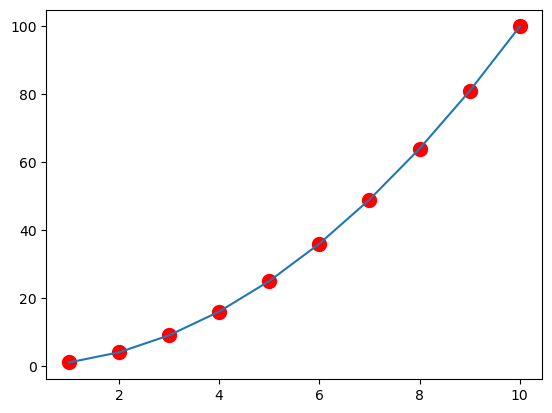

In [107]:
x=range(1,11)
y=np.square(range(1,11))
plt.scatter(x,y,c='Red',s=100)
plt.plot(x,y)

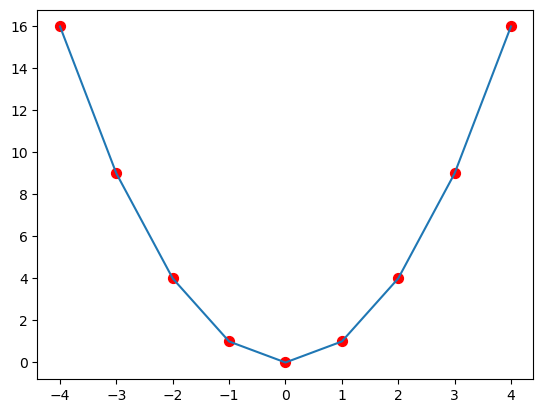

In [105]:
x=range(-4,5)
y=[i*i for i in x]
plt.scatter(x,y,c='Red',s=50)
plt.plot(x,y)

In [111]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

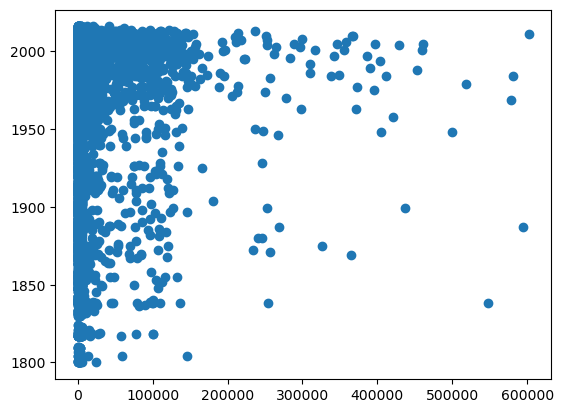

In [113]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.scatter(col1,col2)

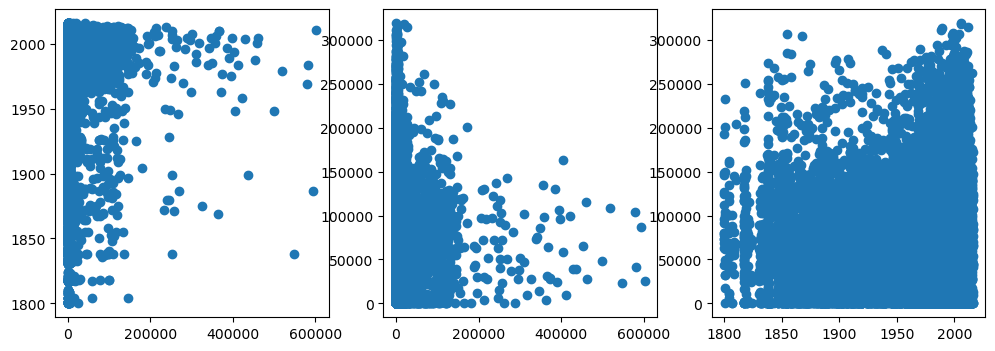

In [115]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.scatter(col1,col2)
plt.subplot(1,3,2)
plt.scatter(col1,col3)
plt.subplot(1,3,3)
plt.scatter(col2,col3)

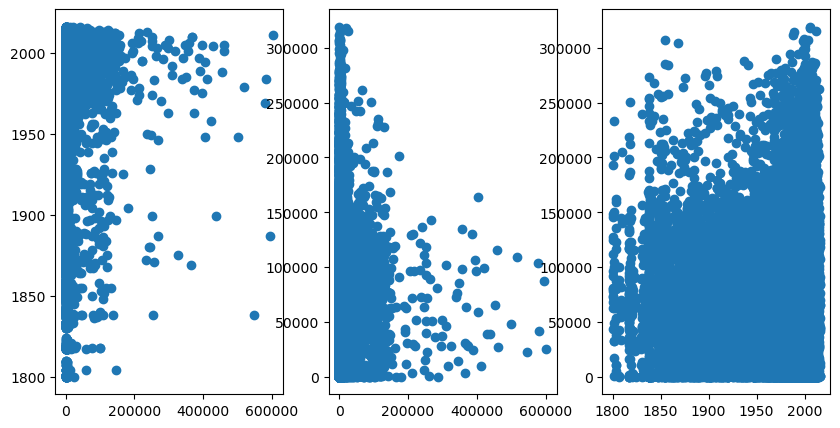

In [119]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.scatter(col1,col2)
plt.subplot(1,3,2)
plt.scatter(col1,col3)
plt.subplot(1,3,3)
plt.scatter(col2,col3)

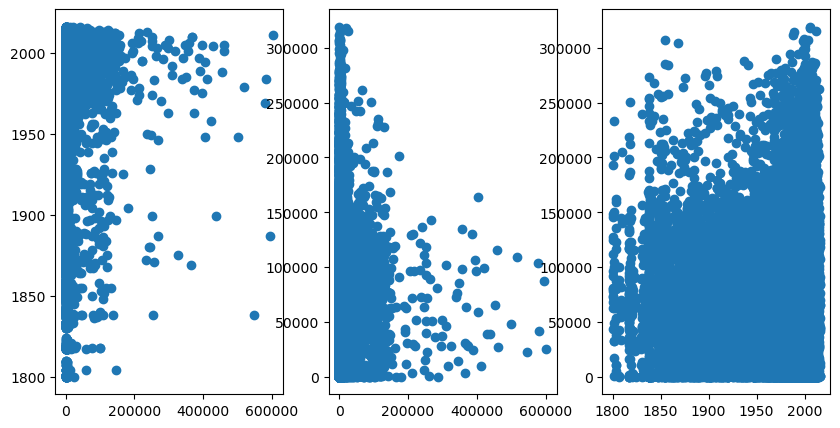

In [129]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(10,5))
plt.subplot(1,3,1).scatter(col1,col2)

plt.subplot(1,3,2).scatter(col1,col3)

plt.subplot(1,3,3).scatter(col2,col3)

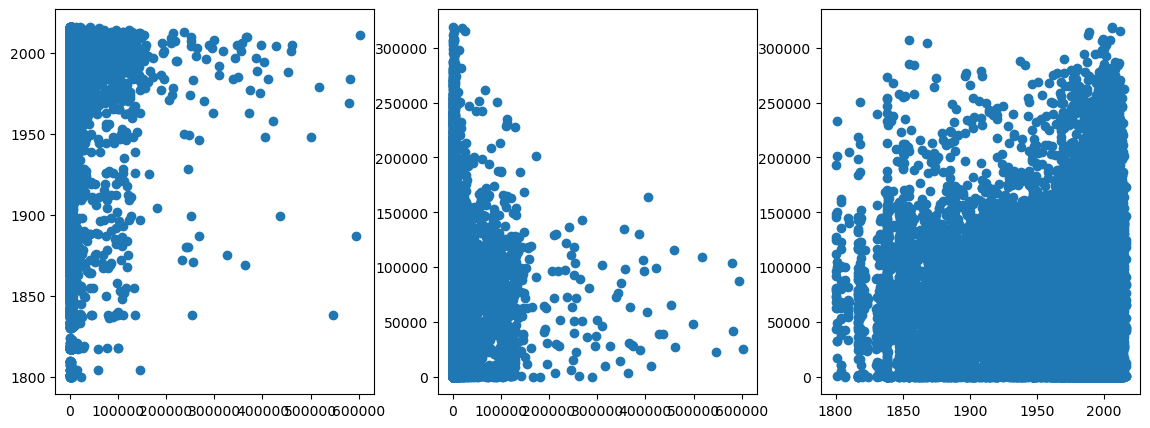

In [135]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(14,5))
plt.subplot(1,3,1).scatter(col1,col2)

plt.subplot(1,3,2).scatter(col1,col3)

plt.subplot(1,3,3).scatter(col2,col3)

# Co-relation :

In [139]:
visa_df.corr()

ValueError: could not convert string to float: 'EZYV01'

In [141]:
visa_df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [145]:
wine_df=pd.read_csv(r"E:\Python Projects\Data Files\winequality_red.csv")
wine_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [147]:
wine_df.corr(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


<Axes: >

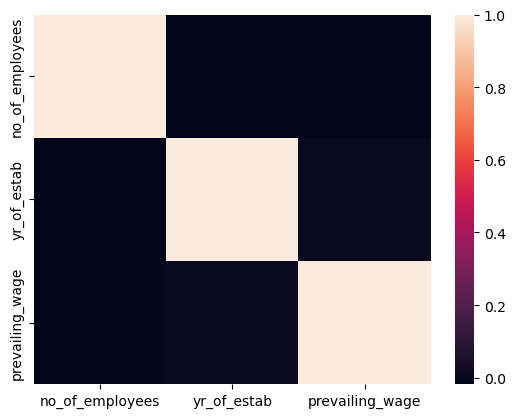

In [151]:
visa_corr=visa_df.corr(numeric_only=True)
sns.heatmap(visa_corr)

<Axes: >

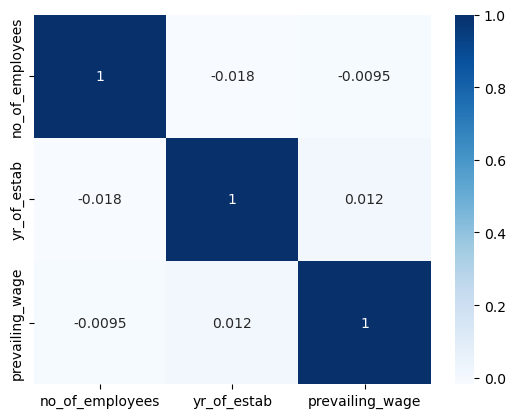

In [153]:
visa_corr=visa_df.corr(numeric_only=True)
sns.heatmap(visa_corr,
           annot=True, # To display values inside the box
           cmap='Blues')

<Axes: >

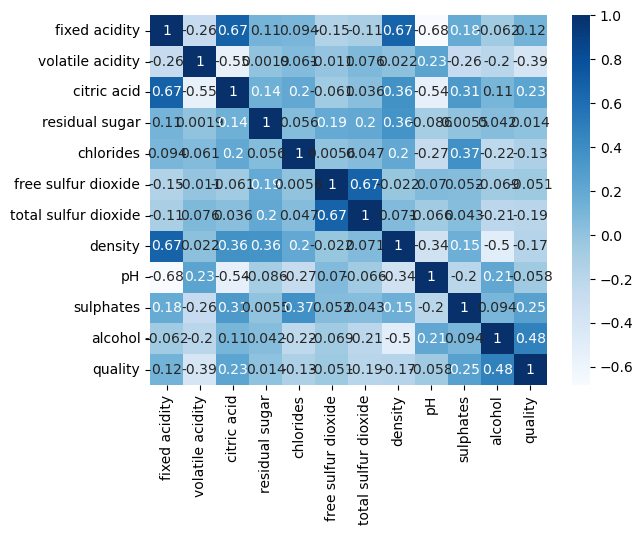

In [157]:
wine_corr=wine_df.corr(numeric_only=True)
sns.heatmap(wine_corr,
           annot=True, # To display values inside the box
           cmap='Blues')

<Axes: >

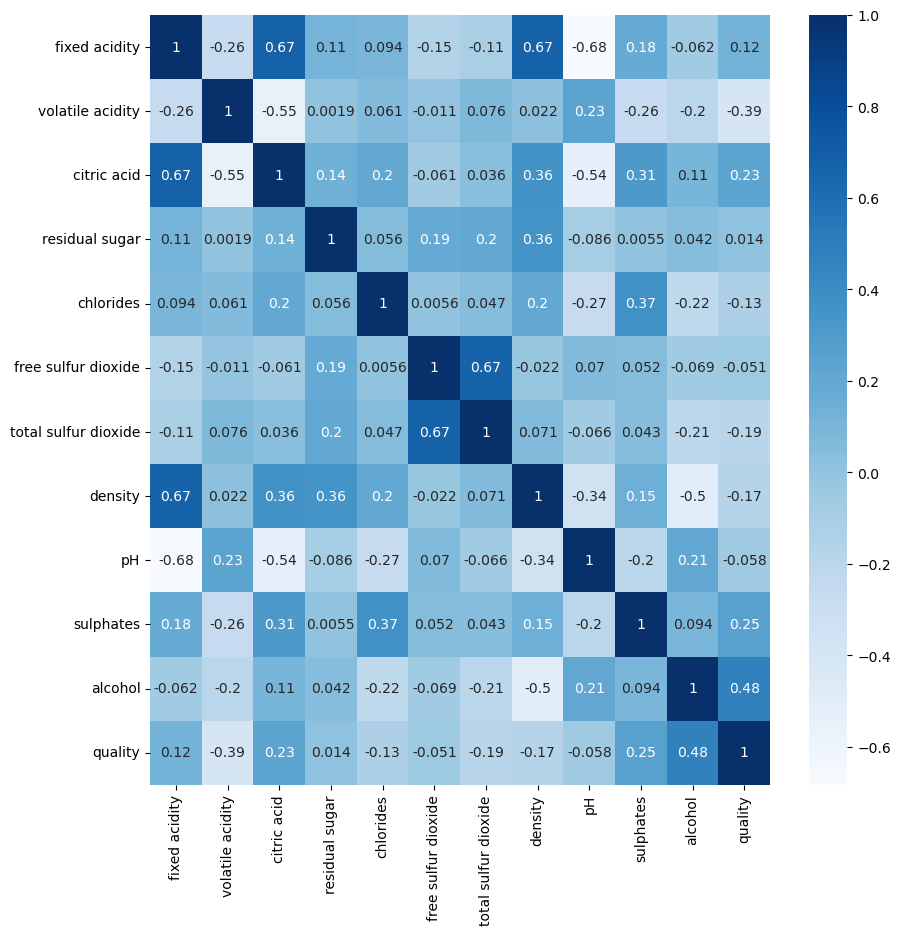

In [161]:
wine_corr=wine_df.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(wine_corr,
           annot=True, # To display values inside the box
           cmap='Blues')

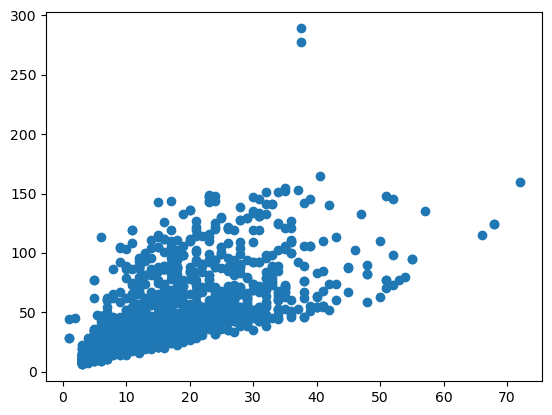

In [163]:
col1=wine_df['free sulfur dioxide']
col2=wine_df['total sulfur dioxide']
plt.scatter(col1,col2)

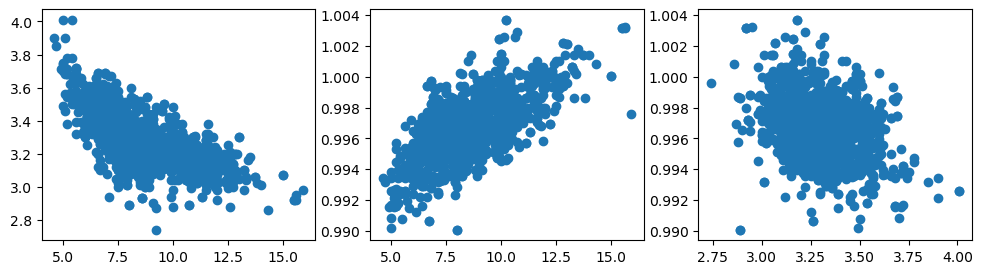

In [171]:
col1=wine_df['fixed acidity']
col2=wine_df['pH']
col3=wine_df['density']
plt.figure(figsize=(12,3))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col1,col3)
plt.subplot(1,3,3).scatter(col2,col3)

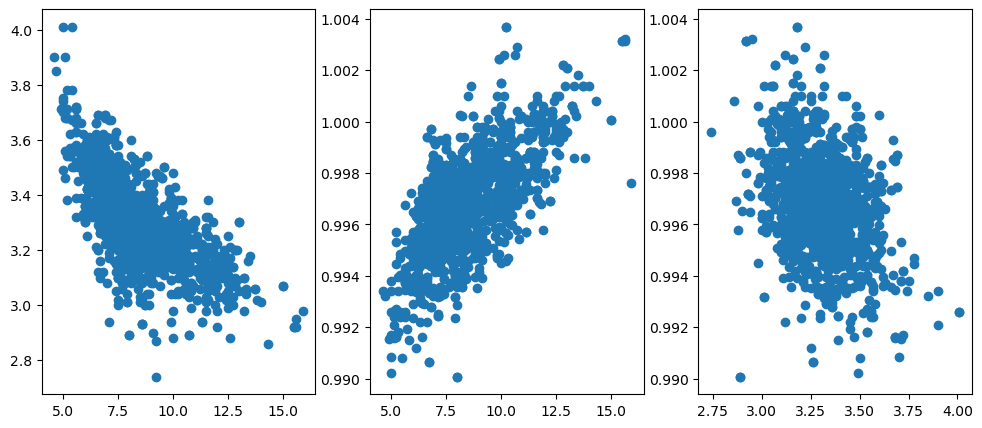

In [173]:
col1=wine_df['fixed acidity']
col2=wine_df['pH']
col3=wine_df['density']
plt.figure(figsize=(12,5))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col1,col3)
plt.subplot(1,3,3).scatter(col2,col3)

- Generally we need to have a good correlation between input and output columns

- We dont want a relation between input columns

In [176]:
wine_corr.sort_values(by='quality')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


In [178]:
wine_corr.iloc[:,-1]

fixed acidity           0.124052
volatile acidity       -0.390558
citric acid             0.226373
residual sugar          0.013732
chlorides              -0.128907
free sulfur dioxide    -0.050656
total sulfur dioxide   -0.185100
density                -0.174919
pH                     -0.057731
sulphates               0.251397
alcohol                 0.476166
quality                 1.000000
Name: quality, dtype: float64

In [180]:
pd.DataFrame(wine_corr.iloc[:,-1])

,quality
fixed acidity,0.124052
volatile acidity,-0.390558
citric acid,0.226373
residual sugar,0.013732
chlorides,-0.128907
free sulfur dioxide,-0.050656
total sulfur dioxide,-0.185100
density,-0.174919
pH,-0.057731
sulphates,0.251397


In [182]:
pd.DataFrame(wine_corr.iloc[:,-1]).sort_values(by='quality',ascending=False)

,quality
quality,1.000000
alcohol,0.476166
sulphates,0.251397
citric acid,0.226373
fixed acidity,0.124052
residual sugar,0.013732
free sulfur dioxide,-0.050656
pH,-0.057731
chlorides,-0.128907
density,-0.174919


In [184]:
wine_corr.sort_values(by='quality',ascending=False)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
quality,0.124052,-0.390558,0.226373,0.013732,-0.128907,-0.050656,-0.185100,-0.174919,-0.057731,0.251397,0.476166,1.000000
alcohol,-0.061668,-0.202288,0.109903,0.042075,-0.221141,-0.069408,-0.205654,-0.496180,0.205633,0.093595,1.000000,0.476166
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
